![openclassrooms](https://s3.eu-west-1.amazonaws.com/course.oc-static.com/courses/6204541/1+HnqdJ-5ofxiPP9HIxdNdpw.jpeg)

# Générez des graphiques complexes avec Seaborn

Habituellement, les graphiques du reporting mensuels sont réalisés avec matplotlib. Votre ultime tâche va être d’améliorer quelque peu le visuel de ces derniers et de les reprendre avec Seaborn.

L’objectif va être de reprendre le travail qui avait été réalisé précédemment, avec Seaborn. En plus de ces graphiques, quelques demandes additionnelles ont été glissées par votre manager.

Les graphiques à produire sont donc :
- la proportion de prêt par type de prêt
- le bénéfice mensuel réalisé en fonction du revenu du client
- la distribution des bénéfices réalisés
- le bénéfice mensuel total réalisé par agence

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Pour réaliser les différents graphiques, nous utiliserons le fichier de prêt enrichi ([c.f. exercice précédent](https://colab.research.google.com/github/OpenClassrooms-Student-Center/fr-4452741-decouvrez-les-librairies-python-pour-la-data-science/blob/main/notebooks/P2/P2C3%20-%20Filtrez%20les%20donn%C3%A9es%20du%20data%20frame%20-%20correction.ipynb)) que vous trouverez [à cette adresse](https://raw.githubusercontent.com/OpenClassrooms-Student-Center/fr-4452741-decouvrez-les-librairies-python-pour-la-data-science/main/data/prets_final.csv) :

In [2]:
prets = pd.read_csv('https://raw.githubusercontent.com/OpenClassrooms-Student-Center/fr-4452741-decouvrez-les-librairies-python-pour-la-data-science/main/data/prets_final.csv')

prets.head()

,identifiant,ville,CP,revenu,remboursement,duree,type,taux_interet,taux_endettement,cout_total,benefices,risque
0,0,TOULOUSE,31100,3669.0,1130.05,240,immobilier,1.168,30.80,271212.0,131.99,Non
1,1,PARIS,75009,5310.0,240.00,64,automobile,3.701,4.52,15360.0,23.69,Non
2,1,PARIS,75009,5310.0,1247.85,300,immobilier,1.173,23.50,374355.0,182.97,Non
3,2,MARSEILLE,13010,1873.0,552.54,240,immobilier,0.972,29.50,132609.6,53.71,Non
4,3,MARSEILLE,13010,1684.0,586.03,180,immobilier,1.014,34.80,105485.4,44.57,Non


## 1. proportion de prêt par type de prêt.

Pour réaliser ce graphique, vous pouvez naturellement ré-utiliser l'agrégation, mais le mieux est de laisser travailler seaborn, en utilisant la fonction [countplot](https://seaborn.pydata.org/generated/seaborn.countplot.html)

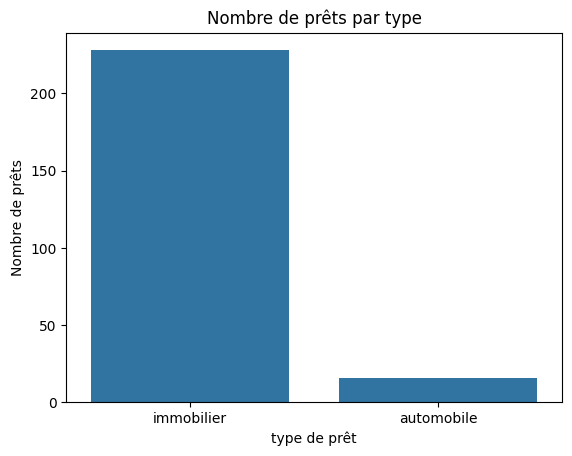

In [4]:
sns.countplot(data=prets, x="type")
plt.title('Nombre de prêts par type')
plt.xlabel('type de prêt')
plt.ylabel('Nombre de prêts')

plt.show()

## 2. bénéfice mensuel réalisé en fonction du revenu du client - prêts immobiliers

Pour ce graphique, vous ajouterez simplement en couleur l'information de l'agence où a été réalisé le prêt

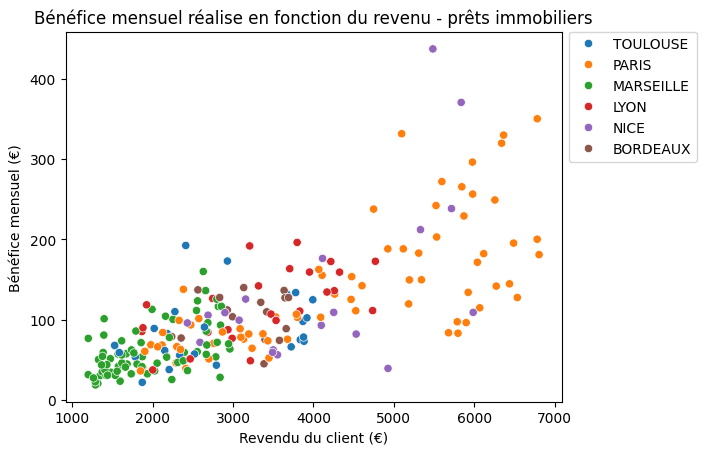

In [8]:
prets_immobiliers = prets[prets["type"] == 'immobilier']

sns.scatterplot(data=prets_immobiliers, x="revenu", y="benefices", hue="ville")

plt.title('Bénéfice mensuel réalise en fonction du revenu - prêts immobiliers')
plt.xlabel('Revendu du client (€)')
plt.ylabel('Bénéfice mensuel (€)')
plt.legend(bbox_to_anchor=(1, 1.02))


plt.show()

## 3. La distribution des bénéfices réalisés

Nous souhaitons avoir un histogramme classique et un à densité. Vous aurez besoin des fonctions :
- [histplot](https://seaborn.pydata.org/generated/seaborn.histplot.html) pour l'histogramme
- [kdeplot](https://seaborn.pydata.org/generated/seaborn.kdeplot.html) pour le diagramme à densité

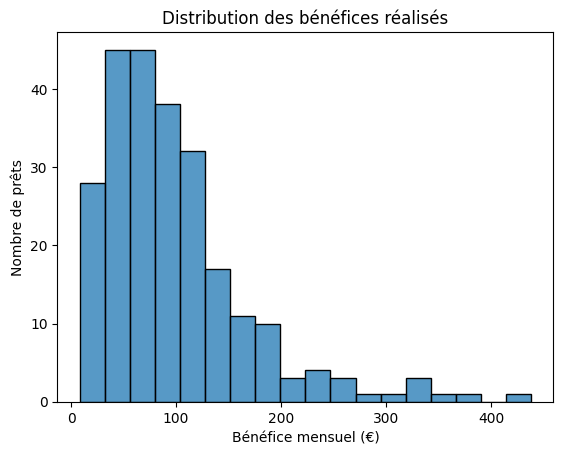

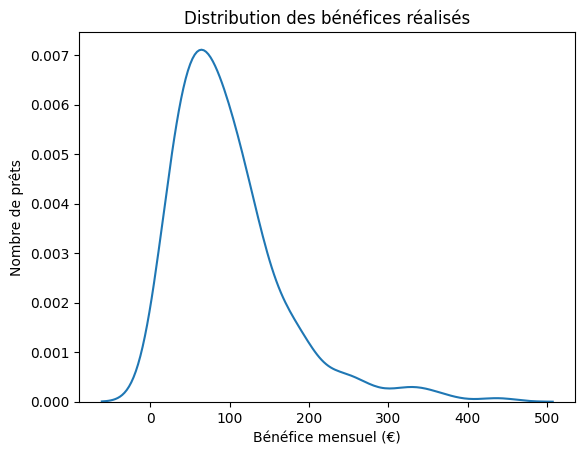

In [10]:
sns.histplot (data=prets, x="benefices")

plt.title('Distribution des bénéfices réalisés')
plt.xlabel('Bénéfice mensuel (€)')
plt.ylabel('Nombre de prêts')

plt.show()

sns.kdeplot(data=prets, x="benefices")

plt.title('Distribution des bénéfices réalisés')
plt.xlabel('Bénéfice mensuel (€)')
plt.ylabel('Nombre de prêts')

plt.show()

## 4. bénéfice mensuel total réalisé par agence

Pour ce graphique, on souhaite avoir 2 barres par ville : une pour chaque type de prêt

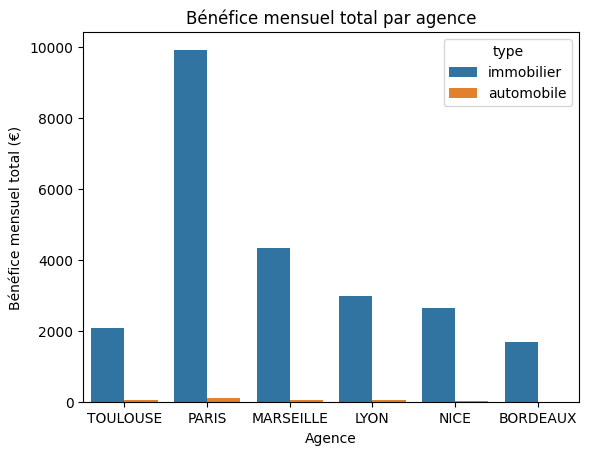

In [15]:
sns.barplot(data=prets, x="ville", y="benefices", hue="type", estimator=np.sum, errorbar=None)

plt.title('Bénéfice mensuel total par agence')
plt.xlabel('Agence')
plt.ylabel('Bénéfice mensuel total (€)')
#plt.legend(bbox_to_anchor=(1, 1.02))

plt.show()


Top !! Que diriez vous de comparer à présent le travail réalisé avec [ma correction](https://colab.research.google.com/github/OpenClassrooms-Student-Center/fr-4452741-decouvrez-les-librairies-python-pour-la-data-science/blob/main/notebooks/P3/P3C4%20-%20G%C3%A9n%C3%A9rez%20des%20graphiques%20complexes%20avec%20Seaborn%20-%20correction.ipynb) ?